In [24]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

# -----------------------------------------------------------
# Helper function to load point-based CSV datasets
# -----------------------------------------------------------
def load_point_csv(path, lat_col, lon_col, crs="EPSG:4326", dedup_col=None):
 
    df = pd.read_csv(path)

    # Optionally drop duplicates (e.g., multiple rows per stop)
    if dedup_col is not None and dedup_col in df.columns:
        df = df.drop_duplicates(subset=[dedup_col])

    # Remove rows with missing coordinates
    df = df.dropna(subset=[lat_col, lon_col])

    # Create point geometries
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs=crs
    )

    # Convert to analysis CRS (NAD83 / New York Long Island - EPSG:2263)
    return gdf.to_crs(2263)


# -----------------------------------------------------------
# 1. Load Required Facility Datasets
# -----------------------------------------------------------

# ---------- Subway Stations ----------
subway = load_point_csv(
    "data/MTA_Subway_Stations.csv",
    lat_col="GTFS Latitude",
    lon_col="GTFS Longitude"
)

# ---------- NYCHA Facilities ----------
nycha = load_point_csv(
    "data/NYCHA_Facilities_and_Service_Centers.csv",
    lat_col="Latitude",
    lon_col="Longitude"
)

# ---------- MTA Bus Stops ----------
bus_stops = load_point_csv(
    "data/MTA_Bus_Stops.csv",
    lat_col="Latitude",       
    lon_col="Longitude",
    dedup_col="Stop ID"       
)

# ---------- Social Service Facilities (from FacDB) ----------
fac_all = pd.read_csv("data/Facilities_Database.csv")

# Define which facility groups are considered social services
social_fac_groups = [
    "ADULT SERVICES",
    "HUMAN SERVICES",
    "CHILD SERVICES AND WELFARE",
    "YOUTH SERVICES",
]

# Filter dataset to only social service-related facilities
social_df = fac_all[fac_all["facgroup"].isin(social_fac_groups)].copy()

# Remove missing geometries
social_df = social_df.dropna(subset=["geometry"])

# Convert WKT geometry text into actual geometry objects
social_df["geometry"] = social_df["geometry"].apply(wkt.loads)

# Convert into GeoDataFrame (FacDB geometry is in EPSG:2263)
social_services = gpd.GeoDataFrame(
    social_df,
    geometry="geometry",
    crs="EPSG:2263"
)


# -----------------------------------------------------------
# 2. Load Schools (shapefile → points)
# -----------------------------------------------------------
schools = gpd.read_file("data/SchoolPoints_APS_2024_08_28/SchoolPoints_APS_2024_08_28.shp")
schools = schools.to_crs(2263)


# -----------------------------------------------------------
# 3. Load Parks (WKT multipolygon → polygons)
# -----------------------------------------------------------
parks_df = pd.read_csv("data/Parks_Zones.csv")

# Convert WKT text → geometry object
parks_df["geometry"] = parks_df["multipolygon"].apply(wkt.loads)

# Convert into GeoDataFrame (original CRS = EPSG:4326)
parks = gpd.GeoDataFrame(parks_df, geometry="geometry", crs="EPSG:4326")

# Convert to analysis CRS
parks = parks.to_crs(2263)


# -----------------------------------------------------------
# 4. Load Top 5 Priority Tracts (from your priority score file)
# -----------------------------------------------------------
df = pd.read_csv("NYC_Public_Restroom_Priority_Score.csv", dtype={"GEOID": str})

# Extract GEOIDs for the top 5 priority tracts
top5_ids = (
    df[df["Priority_Class"] == 1]
    .sort_values("Priority_Score", ascending=False)
    .head(5)["GEOID"]
    .tolist()
)

# Load full Census Tract shapefile
tracts = gpd.read_file("tl_2023_36_tract/tl_2023_36_tract.shp")

# Keep only NYC counties
NYC_COUNTIES = {"005", "047", "061", "081", "085"}
tracts = tracts[
    (tracts["STATEFP"] == "36") &
    (tracts["COUNTYFP"].isin(NYC_COUNTIES))
].copy()

# Convert CRS
tracts = tracts.to_crs(2263)

# Ensure GEOID is string
tracts["GEOID"] = tracts["GEOID"].astype(str)

# Filter only top 5 tracts
tracts_top5 = tracts[tracts["GEOID"].isin(top5_ids)].copy()

# Merge priority score for sorting/display
tracts_top5 = tracts_top5.merge(
    df[["GEOID", "Priority_Score"]],
    on="GEOID",
    how="left"
).sort_values("Priority_Score", ascending=False)

tracts_top5[["GEOID", "NAMELSAD", "Priority_Score"]]

,GEOID,NAMELSAD,Priority_Score
2,36061014602,Census Tract 146.02,0.979245
4,36085027705,Census Tract 277.05,0.925639
0,36081046700,Census Tract 467,0.924856
3,36081066403,Census Tract 664.03,0.860687
1,36085027302,Census Tract 273.02,0.840500


In [25]:
import numpy as np

# -----------------------------------------------------------
# 1) Prepare geometry for the top 5 tracts
# -----------------------------------------------------------
# Keep only GEOID and geometry for spatial operations
top5_geom = tracts_top5[["GEOID", "geometry"]].copy()


# -----------------------------------------------------------
# 2) Helper: find point features near top 5 tracts
# -----------------------------------------------------------
def points_near_top5(points_gdf, label, buffer_ft=1500):
   
    if points_gdf.empty:
        print(f"{label}: input GeoDataFrame is empty.")
        return points_gdf.iloc[0:0].copy()

    # Buffer the tract geometries
    buffered = top5_geom.copy()
    buffered["geometry"] = buffered.geometry.buffer(buffer_ft)

    # Spatial join: points that intersect the buffered polygons
    joined = gpd.sjoin(points_gdf, buffered, how="inner", predicate="intersects")

    print(f"{label} within ~{buffer_ft} ft of top 5 tracts:", len(joined))
    return joined


# -----------------------------------------------------------
# 3) Helper: find park polygons near top 5 tracts
# -----------------------------------------------------------
def parks_near_top5(parks_gdf, label="Parks (polygons)", buffer_ft=1500):

    if parks_gdf.empty:
        print(f"{label}: input GeoDataFrame is empty.")
        return parks_gdf.iloc[0:0].copy()

    # Buffer the tract geometries
    buffered = top5_geom.copy()
    buffered["geometry"] = buffered.geometry.buffer(buffer_ft)

    # Spatial join: polygons that intersect the buffered polygons
    joined = gpd.sjoin(parks_gdf, buffered, how="inner", predicate="intersects")

    print(f"{label} within ~{buffer_ft} ft of top 5 tracts:", len(joined))
    return joined


# -----------------------------------------------------------
# 4) Compute nearby facilities for each dataset
# -----------------------------------------------------------
bus_near      = points_near_top5(bus_stops,       "Bus stops")
subway_near   = points_near_top5(subway,          "Subway stations")
social_near   = points_near_top5(social_services, "Social service facilities")
nycha_near    = points_near_top5(nycha,           "NYCHA facilities")
schools_near  = points_near_top5(schools,         "Schools")
parks_near    = parks_near_top5(parks,            "Parks (polygons)")

Bus stops within ~1500 ft of top 5 tracts: 200
Subway stations within ~1500 ft of top 5 tracts: 5
Social service facilities within ~1500 ft of top 5 tracts: 97
NYCHA facilities within ~1500 ft of top 5 tracts: 4
Schools within ~1500 ft of top 5 tracts: 22
Parks (polygons) within ~1500 ft of top 5 tracts: 10


In [26]:
from shapely.geometry import Point

# -----------------------------------------------------------
# 0) Facility weights (can be tuned)
# -----------------------------------------------------------
FACILITY_WEIGHTS = {
    "subway": 2.0,          # commuter hubs
    "bus": 1.0,             # frequent but more local
    "schools": 3.0,         # strong daytime demand
    "parks": 1.5,           # recreation-based demand
    "nycha": 2.5,           # low-income residents
    "social": 3.5           # vulnerable / service-seeking population
}


# -----------------------------------------------------------
# 1) Collect facility points for a single tract (as demand)
# -----------------------------------------------------------
def get_facility_points_for_tract(geoid):
    
    dfs = []

    # Subway stations (points)
    if 'subway_near' in globals() and not subway_near.empty:
        sub = subway_near[subway_near["GEOID"] == geoid].copy()
        if not sub.empty:
            sub["weight"] = FACILITY_WEIGHTS["subway"]
            dfs.append(sub[["geometry", "weight"]])

    # Bus stops (points)
    if 'bus_near' in globals() and not bus_near.empty:
        bs = bus_near[bus_near["GEOID"] == geoid].copy()
        if not bs.empty:
            bs["weight"] = FACILITY_WEIGHTS["bus"]
            dfs.append(bs[["geometry", "weight"]])

    # Schools (points)
    if 'schools_near' in globals() and not schools_near.empty:
        sch = schools_near[schools_near["GEOID"] == geoid].copy()
        if not sch.empty:
            sch["weight"] = FACILITY_WEIGHTS["schools"]
            dfs.append(sch[["geometry", "weight"]])

    # Parks (polygons → centroids)
    if 'parks_near' in globals() and not parks_near.empty:
        pk = parks_near[parks_near["GEOID"] == geoid].copy()
        if not pk.empty:
            pk["geometry"] = pk.geometry.centroid
            pk["weight"] = FACILITY_WEIGHTS["parks"]
            dfs.append(pk[["geometry", "weight"]])

    # NYCHA facilities (points)
    if 'nycha_near' in globals() and not nycha_near.empty:
        ny = nycha_near[nycha_near["GEOID"] == geoid].copy()
        if not ny.empty:
            ny["weight"] = FACILITY_WEIGHTS["nycha"]
            dfs.append(ny[["geometry", "weight"]])

    # Social service facilities (points)
    if 'social_near' in globals() and not social_near.empty:
        ss = social_near[social_near["GEOID"] == geoid].copy()
        if not ss.empty:
            ss["weight"] = FACILITY_WEIGHTS["social"]
            dfs.append(ss[["geometry", "weight"]])

    if len(dfs) == 0:
        # No facilities around this tract
        return gpd.GeoDataFrame(
            columns=["geometry", "weight"],
            geometry="geometry",
            crs=tracts_top5.crs
        )

    facilities = gpd.GeoDataFrame(
        pd.concat(dfs, ignore_index=True),
        geometry="geometry",
        crs=tracts_top5.crs
    )
    return facilities


# -----------------------------------------------------------
# 2) Generate grid candidate points within a tract
# -----------------------------------------------------------
def generate_grid_candidates_for_tract(geoid, cell_size_ft=200):
    
    tract_row = tracts_top5[tracts_top5["GEOID"] == geoid]
    if tract_row.empty:
        raise ValueError(f"GEOID {geoid} not found in tracts_top5")

    geom = tract_row.geometry.iloc[0]  # shapely polygon
    minx, miny, maxx, maxy = geom.bounds

    xs = np.arange(minx, maxx, cell_size_ft)
    ys = np.arange(miny, maxy, cell_size_ft)

    points = []
    for x in xs:
        for y in ys:
            pt = Point(x, y)
            # Only keep points inside the tract polygon
            if geom.contains(pt):
                points.append(pt)

    if not points:
        # Fallback: at least use tract centroid as one candidate
        points = [geom.centroid]

    candidates = gpd.GeoDataFrame(geometry=points, crs=tracts_top5.crs)
    return candidates


# -----------------------------------------------------------
# 3) p-median with grid candidates (p = 1)
# -----------------------------------------------------------
def p_median_one_tract_grid(geoid, cell_size_ft=200):
   
    facilities = get_facility_points_for_tract(geoid)

    # If no facilities around, fall back to tract centroid
    tract_row = tracts_top5[tracts_top5["GEOID"] == geoid].iloc[0]
    tract_geom = tract_row.geometry

    if facilities.empty:
        centroid = tract_geom.centroid
        one_point_gdf = gpd.GeoDataFrame(geometry=[centroid], crs=tracts_top5.crs)
        return centroid, 0.0, facilities, one_point_gdf

    candidates = generate_grid_candidates_for_tract(geoid, cell_size_ft=cell_size_ft)

    demand_points = facilities.geometry.values
    weights = facilities["weight"].values

    best_point = None
    best_cost = np.inf

    # Evaluate each candidate point
    for cand in candidates.geometry:
        # distance to each demand point (in feet)
        dists = np.array([cand.distance(pt) for pt in demand_points])
        cost = np.sum(dists * weights)

        if cost < best_cost:
            best_cost = cost
            best_point = cand

    return best_point, best_cost, facilities, candidates


# -----------------------------------------------------------
# 4) Run p-median for all top 5 tracts and build final table
# -----------------------------------------------------------
results = []

for gid in tracts_top5["GEOID"]:
    best_point, best_cost, _, _ = p_median_one_tract_grid(
        geoid=gid,
        cell_size_ft=200  
    )
    results.append({
        "GEOID": gid,
        "p_median_cost": best_cost,
        "geometry": best_point
    })

# GeoDataFrame with optimal sites in EPSG:2263
candidate_sites = gpd.GeoDataFrame(results, geometry="geometry", crs=tracts_top5.crs)

# --- Add lat / lon (convert to WGS84) ---
candidate_sites_ll = candidate_sites.to_crs(4326).copy()
candidate_sites_ll["lat"] = candidate_sites_ll.geometry.y
candidate_sites_ll["lon"] = candidate_sites_ll.geometry.x

# --- Prepare tract info: borough, tract_name, Priority_Score ---
tract_info = tracts_top5.copy()

if "borough" not in tract_info.columns:
    borough_map = {
        "005": "Bronx",
        "047": "Brooklyn",
        "061": "Manhattan",
        "081": "Queens",
        "085": "Staten Island",
    }
    tract_info["borough"] = tract_info["COUNTYFP"].map(borough_map)

# Tract name from NAMELSAD
tract_info["tract_name"] = tract_info["NAMELSAD"]

# Keep only needed columns
tract_info_small = tract_info[["GEOID", "borough", "tract_name", "Priority_Score"]]

# --- Merge candidate sites with tract info ---
final_df = candidate_sites_ll.merge(
    tract_info_small,
    on="GEOID",
    how="left"
)

final_df = final_df[[
    "GEOID",
    "borough",
    "tract_name",
    "Priority_Score",
    "lat",
    "lon",
    "p_median_cost"
]]

final_df

,GEOID,borough,tract_name,Priority_Score,lat,lon,p_median_cost
0,36061014602,Manhattan,Census Tract 146.02,0.979245,40.779072,-73.948929,234625.647181
1,36085027705,Staten Island,Census Tract 277.05,0.925639,40.585567,-74.160108,136325.796921
2,36081046700,Queens,Census Tract 467,0.924856,40.743245,-73.874868,311540.689493
3,36081066403,Queens,Census Tract 664.03,0.860687,40.653484,-73.733611,59459.565164
4,36085027302,Staten Island,Census Tract 273.02,0.840500,40.597358,-74.137211,289383.903668


In [27]:
import folium

def plot_tract_facilities_folium(geoid, zoom_start=15):

    # --- 1) Select tract and convert to WGS84 (EPSG:4326) ---
    tract_2263 = tracts_top5[tracts_top5["GEOID"] == geoid]
    tract = tract_2263.to_crs(4326)

    # Center of the map
    center_y = tract.geometry.iloc[0].centroid.y
    center_x = tract.geometry.iloc[0].centroid.x

    # --- 2) Select optimal site for this tract ---
    site_2263 = candidate_sites[candidate_sites["GEOID"] == geoid]
    site = site_2263.to_crs(4326)

    # --- 3) Filter nearby facilities for this tract and convert CRS ---
    def _sel_to_4326(gdf_near):
        sub = gdf_near[gdf_near["GEOID"] == geoid].copy()
        if sub.empty:
            return sub  # empty GeoDataFrame
        return sub.to_crs(4326)

    subway_gdf   = _sel_to_4326(subway_near)
    schools_gdf  = _sel_to_4326(schools_near)
    parks_gdf    = _sel_to_4326(parks_near)
    nycha_gdf    = _sel_to_4326(nycha_near)
    bus_gdf      = _sel_to_4326(bus_near)
    social_gdf   = _sel_to_4326(social_near)

    # --- 4) Create folium map ---
    m = folium.Map(location=[center_y, center_x], zoom_start=zoom_start)

    # Tract boundary (yellow fill, red outline)
    folium.GeoJson(
        tract.geometry.iloc[0],
        style_function=lambda x: {
            "color": "red",
            "weight": 2,
            "fillColor": "yellow",
            "fillOpacity": 0.3
        }
    ).add_to(m)

    # --- 5) Add facilities as CircleMarkers ---

    # Subway
    for _, row in subway_gdf.iterrows():
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            color="blue",
            fill=True,
            fill_opacity=1,
            popup="Subway station"
        ).add_to(m)

    # Schools
    for _, row in schools_gdf.iterrows():
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            color="red",
            fill=True,
            fill_opacity=1,
            popup="School"
        ).add_to(m)

    # Parks (polygon centroid)
    for _, row in parks_gdf.iterrows():
        folium.CircleMarker(
            location=[row.geometry.centroid.y, row.geometry.centroid.x],
            radius=4,
            color="green",
            fill=True,
            fill_opacity=1,
            popup="Park"
        ).add_to(m)

    # NYCHA
    for _, row in nycha_gdf.iterrows():
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            color="orange",
            fill=True,
            fill_opacity=1,
            popup="NYCHA facility"
        ).add_to(m)

    # Bus stops 
    for _, row in bus_gdf.iterrows():
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=2,
            color="purple",
            fill=True,
            fill_opacity=0.7,
            popup="Bus stop"
        ).add_to(m)

    # Social service facilities
    for _, row in social_gdf.iterrows():
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=4,
            color="black",
            fill=True,
            fill_opacity=1,
            popup="Social service facility"
        ).add_to(m)

    # --- 6) Add optimal restroom site (big black X) ---
    if not site.empty:
        s = site.geometry.iloc[0]
        folium.Marker(
            location=[s.y, s.x],
            icon=folium.Icon(color="black", icon="glyphicon-remove"),
            popup=f"Recommended restroom site (GEOID {geoid})"
        ).add_to(m)

    # --- 7) Simple legend (HTML) ---
    legend_html = """
     <div style="position: fixed; 
                 bottom: 30px; left: 30px; width: 210px; 
                 background-color: white; z-index: 9999; 
                 border:2px solid grey; border-radius:6px;
                 padding: 8px; font-size: 12px;">
     <b>Legend</b><br>
     <span style="color: blue;">●</span> Subway<br>
     <span style="color: red;">●</span> Schools<br>
     <span style="color: green;">●</span> Parks<br>
     <span style="color: orange;">●</span> NYCHA<br>
     <span style="color: purple;">●</span> Bus stops<br>
     <span style="color: black;">●</span> Social services<br>
     <span style="color: black;">✖</span> Recommended restroom
     </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    return m

In [28]:
for gid in tracts_top5["GEOID"]:
    print("Plotting", gid)
    m = plot_tract_facilities_folium(gid)
    display(m)   

Plotting 36061014602


Plotting 36085027705


Plotting 36081046700


Plotting 36081066403


Plotting 36085027302


In [29]:
facility_sources = {
    "subway": subway_near,
    "bus": bus_near,
    "schools": schools_near,
    "parks": parks_near,
    "nycha": nycha_near,
    "social": social_near,
}

rows = []
top5_ids = tracts_top5["GEOID"].tolist()

for ftype, gdf in facility_sources.items():
    if gdf is None or gdf.empty:
        continue

    sub = gdf[gdf["GEOID"].isin(top5_ids)]
    if sub.empty:
        continue

    counts = sub.groupby("GEOID").size()

    for geoid, cnt in counts.items():
        rows.append({"GEOID": geoid, "facility_type": ftype, "count": cnt})

fac_counts = pd.DataFrame(rows)

In [30]:
fac_pivot = (
    fac_counts.pivot(
        index="GEOID",
        columns="facility_type",
        values="count",
    )
    .fillna(0)
    .astype(int)
)

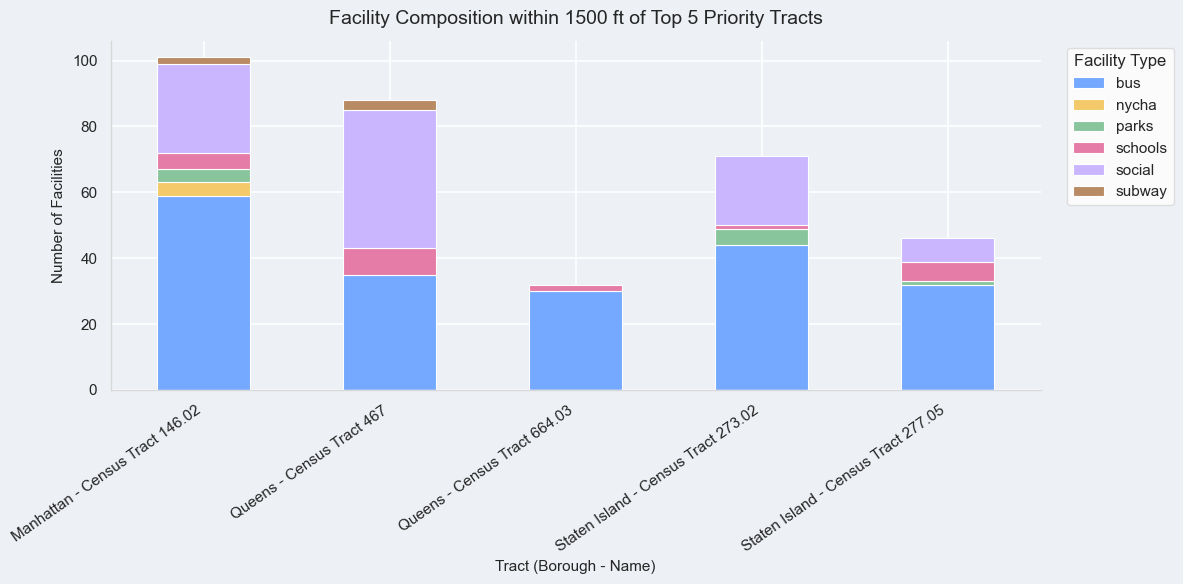

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "#edf0f5",
    "axes.facecolor": "#edf0f5",
    "grid.color": "white",
    "grid.linewidth": 1.2,
    "axes.edgecolor": "#d8d8d8",
    "axes.linewidth": 1.0,
})

# ---------- Build labels ----------
tract_labels = tracts_top5.copy()

# If 'borough' column is missing, create it from COUNTYFP
if "borough" not in tract_labels.columns:
    borough_map = {
        "005": "Bronx",
        "047": "Brooklyn",
        "061": "Manhattan",
        "081": "Queens",
        "085": "Staten Island",
    }
    tract_labels["borough"] = tract_labels["COUNTYFP"].map(borough_map)

# If 'tract_name' is missing, create it
if "tract_name" not in tract_labels.columns:
    tract_labels["tract_name"] = tract_labels["NAMELSAD"]

# Build "Borough - Tract Name"
tract_labels["label"] = (
    tract_labels["borough"] + " - " + tract_labels["tract_name"]
)

# Map GEOID → label
label_map = dict(zip(tract_labels["GEOID"], tract_labels["label"]))

fac_pivot_labeled = fac_pivot.copy()
fac_pivot_labeled.index = fac_pivot_labeled.index.map(label_map)

# -------------------------------------------------------------
# Color Palette 
# -------------------------------------------------------------
palette = {
    "bus":    "#74A9FF",  # skylight blue
    "nycha":  "#F3C969",  # sandy yellow
    "parks":  "#89C59C",  # soft mint green
    "schools":"#E57CA7",  # rose pink
    "social": "#C9B6FF",  # pastel lavender
    "subway": "#B98B64",  # warm brown
}

colors = [palette[c] for c in fac_pivot_labeled.columns]

# -------------------------------------------------------------
# Plot stacked bar chart
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

fac_pivot_labeled.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="white",
    linewidth=0.8
)

# -------------------------------------------------------------
# Styling
# -------------------------------------------------------------
ax.set_title(
    "Facility Composition within 1500 ft of Top 5 Priority Tracts",
    fontsize=14,
    pad=12,
)
ax.set_xlabel("Tract (Borough - Name)", fontsize=11)
ax.set_ylabel("Number of Facilities", fontsize=11)

plt.xticks(rotation=35, ha="right")

# Clean modern look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend styling
ax.legend(
    title="Facility Type",
    frameon=True,
    facecolor="white",
    edgecolor="#d8d8d8",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)

plt.tight_layout()
plt.show()

In [32]:
cols_to_merge = ["GEOID", "Priority_Score", "nearest_restroom_dist"]

cols_to_drop = [c for c in ["Priority_Score", "nearest_restroom_dist"] if c in tracts_top5.columns]
tracts_top5 = tracts_top5.drop(columns=cols_to_drop)

# Merge the new information in
tracts_top5 = (
    tracts_top5
    .merge(df[cols_to_merge], on="GEOID", how="left")
    .sort_values("Priority_Score", ascending=False)
)

In [33]:
# Make sure both are in the same CRS (feet)
tracts5 = tracts_top5.to_crs(2263)
candidates_2263 = candidate_sites.to_crs(2263)

before = tracts5["nearest_restroom_dist"].values  

after = []
labels = []

for idx, row in tracts5.iterrows():
    geoid = row["GEOID"]
    # candidate site
    cand = candidates_2263[candidates_2263["GEOID"] == geoid]
    if cand.empty:
        after.append(np.nan)
    else:
        dist = row.geometry.centroid.distance(cand.geometry.iloc[0])
        after.append(dist)

    if "borough" in tracts5.columns and "NAMELSAD" in tracts5.columns:
        labels.append(f"{row['borough']} - {row['NAMELSAD']}")
    else:
        labels.append(geoid)

compare_df = pd.DataFrame({
    "label": labels,
    "before_ft": before,
    "after_ft": after,
})

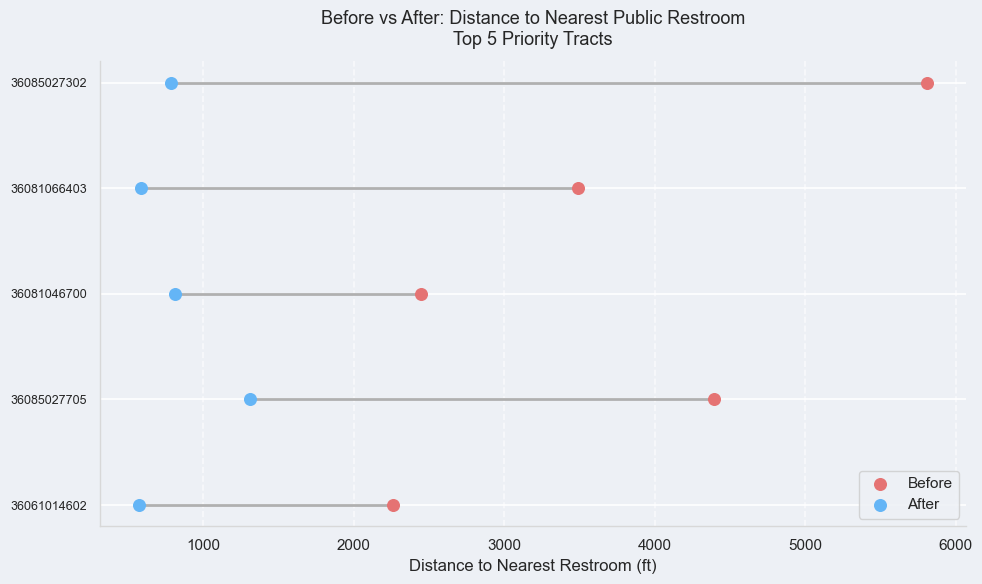

In [34]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "#edf0f5",
    "axes.facecolor": "#edf0f5",
    "grid.color": "white",
    "grid.linewidth": 1.2,
    "axes.edgecolor": "#d8d8d8",
    "axes.linewidth": 1.0,
})

fig, ax = plt.subplots(figsize=(10, 6))

y = np.arange(len(compare_df))

for i, row in compare_df.iterrows():
    # line between before and after
    ax.plot(
        [row["before_ft"], row["after_ft"]],
        [y[i], y[i]],
        color="#b0b0b0",
        linewidth=2,
        zorder=1,
    )
    # before point
    ax.scatter(
        row["before_ft"], y[i],
        color="#e57373", s=70,
        label="Before" if i == 0 else "",
        zorder=2,
    )
    # after point
    ax.scatter(
        row["after_ft"], y[i],
        color="#64b5f6", s=70,
        label="After" if i == 0 else "",
        zorder=3,
    )

ax.set_yticks(y)
ax.set_yticklabels(compare_df["label"], fontsize=9)
ax.set_xlabel("Distance to Nearest Restroom (ft)")
ax.set_title("Before vs After: Distance to Nearest Public Restroom\nTop 5 Priority Tracts",
             fontsize=13, pad=12)

ax.legend(loc="lower right")
ax.grid(axis="x", linestyle="--", alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [36]:
# -----------------------------
# 0) Load priority CSV
# -----------------------------
df = pd.read_csv("NYC_Public_Restroom_Priority_Score.csv", dtype={"GEOID": str})

# Top5 GEOID
top5_ids = (
    df[df["Priority_Class"] == 1]
    .sort_values("Priority_Score", ascending=False)
    .head(5)["GEOID"]
    .tolist()
)

# -----------------------------
# 1) Load SHP + merge needed cols
# -----------------------------
tracts = gpd.read_file("tl_2023_36_tract/tl_2023_36_tract.shp")
NYC_COUNTIES = {"005", "047", "061", "081", "085"}

tracts = tracts[
    (tracts["STATEFP"] == "36") &
    (tracts["COUNTYFP"].isin(NYC_COUNTIES))
].copy()
tracts = tracts.to_crs(2263)
tracts["GEOID"] = tracts["GEOID"].astype(str)

cols_to_merge = ["GEOID", "Priority_Score", "nearest_restroom_dist", "borough", "tract_name"]
tracts_top5 = (
    tracts[tracts["GEOID"].isin(top5_ids)]
    .merge(df[cols_to_merge], on="GEOID", how="left")
    .sort_values("Priority_Score", ascending=False)
)

# -----------------------------
# 2) BEFORE distance
# -----------------------------
before = tracts_top5["nearest_restroom_dist"].values

# Convert candidate sites to feet CRS
tracts5 = tracts_top5.to_crs(2263)
candidates_2263 = candidate_sites.to_crs(2263)

# -----------------------------
# 3) AFTER distance
# -----------------------------
after = []

for idx, row in tracts5.iterrows():
    geoid = row["GEOID"]
    cand = candidates_2263[candidates_2263["GEOID"] == geoid]

    if cand.empty:
        after.append(np.nan)
    else:
        dist = row.geometry.centroid.distance(cand.geometry.iloc[0])
        after.append(dist)

# -----------------------------
# 4) Build final improvement table
# -----------------------------
compare_df = pd.DataFrame({
    "GEOID": tracts_top5["GEOID"].values,
    "borough": tracts_top5["borough"].values,
    "tract_name": tracts_top5["tract_name"].values,
    "Priority_Score": tracts_top5["Priority_Score"].values,
    "before_ft": before,
    "after_ft": after,
})

compare_df["diff_ft"] = compare_df["before_ft"] - compare_df["after_ft"]
compare_df["improvement_pct"] = (compare_df["diff_ft"] / compare_df["before_ft"]) * 100

compare_df["improvement_pct"] = compare_df["improvement_pct"].round(1).astype(str) + "%"

compare_df = compare_df.sort_values("Priority_Score", ascending=False).reset_index(drop=True)
compare_df

,GEOID,borough,tract_name,Priority_Score,before_ft,after_ft,diff_ft,improvement_pct
0,36061014602,Manhattan,Census Tract 146.02,0.979245,2262.520477,574.364590,1688.155887,74.6%
1,36085027705,Staten Island,Census Tract 277.05,0.925639,4390.006230,1306.720649,3083.285581,70.2%
2,36081046700,Queens,Census Tract 467,0.924856,2444.987240,809.464302,1635.522938,66.9%
3,36081066403,Queens,Census Tract 664.03,0.860687,3490.735538,587.792117,2902.943421,83.2%
4,36085027302,Staten Island,Census Tract 273.02,0.840500,5808.150168,787.153323,5020.996845,86.4%
